## 1. Title Page

# Hybrid Neuro-Symbolic Intrusion Detection System
## Balancing Accuracy and Explainability in AI-driven Cybersecurity

**Author:** Neuro-Symbolic IDS Research Team  
**Project Title:** Hybrid Neuro-Symbolic Intrusion Detection System  
**Institution:** Independent Research Project  
**Date:** 2026-03-11

### Abstract
Intrusion detection systems are critical for protecting digital infrastructure from evolving cyber threats. Traditional black-box neural systems can provide strong predictive performance but are often difficult to interpret, while rule-based systems are transparent yet limited in complex pattern discovery. This project proposes a Hybrid Neuro-Symbolic IDS that integrates CNN-based deep representation learning, XGBoost tabular decision modeling, and explicit symbolic reasoning rules. Using NSL-KDD experiments and saved model artifacts, the hybrid approach demonstrates strong detection performance while preserving analyst-readable explanations. The final result is a practical framework for trustworthy AI-driven cybersecurity where high accuracy and explainability are jointly optimized.

## 2. Introduction
Intrusion detection is a foundational capability in cybersecurity operations because modern network threats are frequent, adaptive, and often subtle. High-quality IDS models must detect malicious traffic reliably while minimizing missed attacks and false alarms.

Traditional modeling families face a known trade-off:
- Neural networks and deep learning models can capture complex nonlinear traffic patterns, but they are often difficult to explain.
- Rule-based engines provide human-readable decision logic, but their pattern-learning capacity is limited and brittle under changing attack behavior.

This work introduces a Hybrid Neuro-Symbolic IDS combining:
- CNN for high-level traffic pattern learning
- XGBoost for robust tabular discrimination
- Symbolic IF-THEN rules for explainable evidence

By combining statistical learning with explicit reasoning, the system aims to retain strong predictive power while producing interpretable, auditable decisions for security analysts.

In [1]:
from __future__ import annotations

import json
import re
import subprocess
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk', font_scale=0.85)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'nsl_kdd_processed.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
HYBRID_DIR = MODELS_DIR / 'hybrid'
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'

RANDOM_STATE = 42

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset path: {DATA_PATH}')
print(f'Models dir: {MODELS_DIR}')

Project root: C:\Users\gudal\OneDrive\Desktop\NeuroSymbolic
Dataset path: C:\Users\gudal\OneDrive\Desktop\NeuroSymbolic\data\processed\nsl_kdd_processed.csv
Models dir: C:\Users\gudal\OneDrive\Desktop\NeuroSymbolic\models


## 3. Dataset Description
The experiments use the NSL-KDD intrusion detection dataset (processed form) with mixed categorical and numeric network-traffic features and a binary attack target.

In [2]:
df = pd.read_csv(DATA_PATH)

target_candidates = ['attack_binary', 'attack', 'label', 'class', 'target', 'y']
target_column = next((c for c in target_candidates if c in df.columns), None)
if target_column is None:
    raise ValueError(f'No supported target column found. Available columns: {df.columns.tolist()}')

if target_column == 'attack_binary':
    y = df[target_column].astype(int)
elif df[target_column].dtype == object:
    y = (df[target_column].astype(str).str.lower().str.rstrip('.') != 'normal').astype(int)
else:
    y = (df[target_column].astype(float) > 0).astype(int)

feature_exclusions = {target_column, 'attack', 'difficulty_level'}
feature_columns = [c for c in df.columns if c not in feature_exclusions]
X_raw = df[feature_columns].copy()

categorical_features = X_raw.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numeric_features = [c for c in X_raw.columns if c not in categorical_features]

dataset_summary_df = pd.DataFrame({
    'Metric': ['Total Samples', 'Total Features', 'Attack Ratio', 'Categorical Features', 'Numeric Features'],
    'Value': [
        int(df.shape[0]),
        int(len(feature_columns)),
        f'{100.0 * y.mean():.2f}%',
        int(len(categorical_features)),
        int(len(numeric_features)),
    ],
})

display(dataset_summary_df)

metric_table = pd.DataFrame({
    'Metric': ['Total Samples', 'Total Features', 'Attack Ratio'],
    'Value': [int(df.shape[0]), int(len(feature_columns)), f'{100.0 * y.mean():.2f}%']
})
display(Markdown('### Required Summary Table'))
display(metric_table)

,Metric,Value
0,Total Samples,148517
1,Total Features,41
2,Attack Ratio,48.12%
3,Categorical Features,3
4,Numeric Features,38


### Required Summary Table

,Metric,Value
0,Total Samples,148517
1,Total Features,41
2,Attack Ratio,48.12%


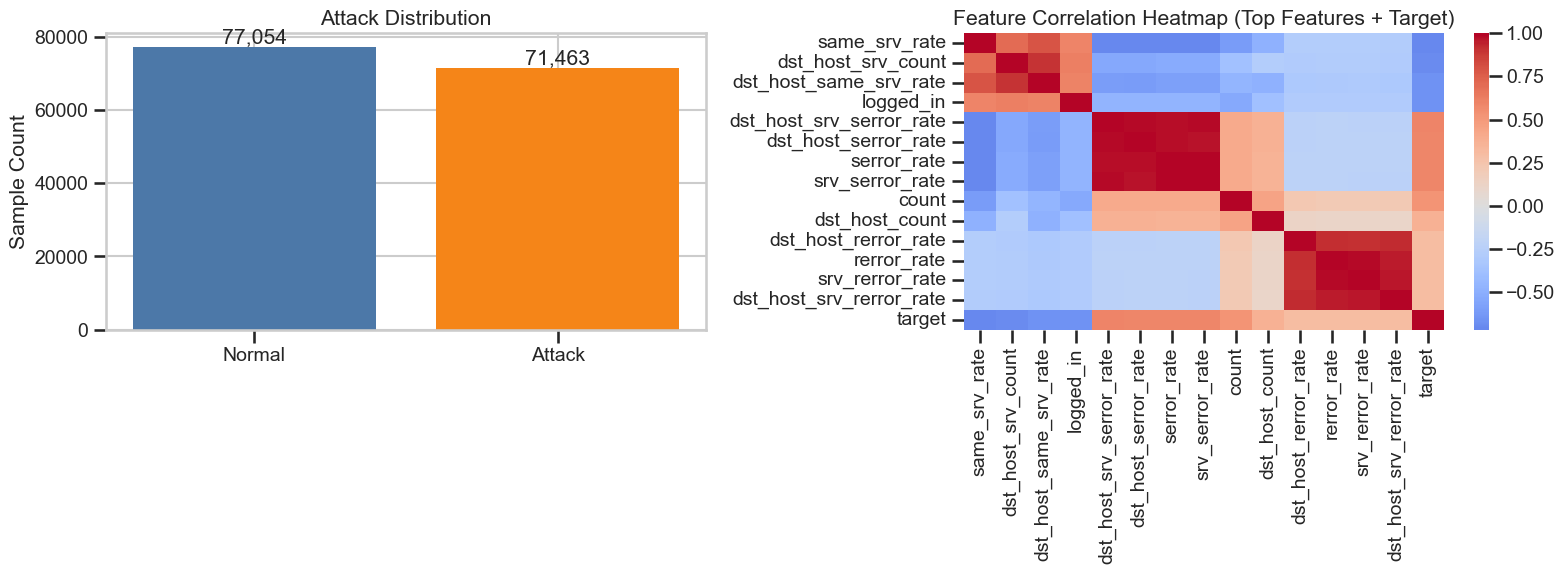

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

attack_counts = y.value_counts().sort_index()
label_map = {0: 'Normal', 1: 'Attack'}
axes[0].bar([label_map.get(i, str(i)) for i in attack_counts.index], attack_counts.values, color=['#4c78a8', '#f58518'])
axes[0].set_title('Attack Distribution')
axes[0].set_ylabel('Sample Count')
for i, v in enumerate(attack_counts.values):
    axes[0].text(i, v, f'{int(v):,}', ha='center', va='bottom')

corr_df = df[numeric_features].copy()
corr_df['target'] = y.values
target_corr = corr_df.corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)
top_features = target_corr.head(14).index.tolist()
heatmap_cols = top_features + ['target']
sns.heatmap(corr_df[heatmap_cols].corr(), cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap (Top Features + Target)')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing
The preprocessing pipeline follows the implementation in src/preprocessing.py:
- Categorical encoding with OneHotEncoder
- Numeric feature scaling with StandardScaler
- Stratified train/test split with 80/20 ratio

This transformation standardizes heterogeneous feature types for both classical and deep learning models.

In [4]:
X = X_raw.copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

cat_cols = X_train_raw.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

preprocessor_path = MODELS_DIR / 'preprocessing_pipeline.joblib'
if preprocessor_path.exists():
    preprocessor = joblib.load(preprocessor_path)
    display(Markdown(f'Loaded saved preprocessing pipeline: {preprocessor_path.name}'))
else:
    preprocessor = ColumnTransformer(
        transformers=[
            ('categorical', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))]), cat_cols),
            ('numeric', Pipeline([('scaler', StandardScaler())]), num_cols),
        ],
        remainder='drop',
    )
    preprocessor.fit(X_train_raw)
    display(Markdown('Saved pipeline not found; fitted a new preprocessing pipeline on current train split.'))

X_train_pre = preprocessor.transform(X_train_raw)
X_test_pre = preprocessor.transform(X_test_raw)

if hasattr(preprocessor, 'get_feature_names_out'):
    feature_names = list(preprocessor.get_feature_names_out())
else:
    feature_names = [f'f_{i}' for i in range(X_train_pre.shape[1])]

shape_table_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Shape': [str(tuple(X_train_pre.shape)), str(tuple(X_test_pre.shape))],
})
display(shape_table_df)

display(Markdown(
    'The preprocessing pipeline expands categorical attributes through one-hot encoding and scales numeric attributes, '
    'producing a unified transformed feature space used by baseline models, XGBoost, and CNN input reshaping.'
))

Loaded saved preprocessing pipeline: preprocessing_pipeline.joblib

,Dataset,Shape
0,Train,"(118813, 118)"
1,Test,"(29704, 118)"


The preprocessing pipeline expands categorical attributes through one-hot encoding and scales numeric attributes, producing a unified transformed feature space used by baseline models, XGBoost, and CNN input reshaping.

## 5. Baseline Machine Learning Models
Baseline models from earlier experiments are loaded from saved artifacts and evaluated on the current reproducible split.

Models included:
- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- Gradient Boosting
- XGBoost
- LightGBM
- SVM Linear
- SVM RBF
- MLP Classifier
- Balanced Random Forest

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Balanced Random Forest,0.9622,0.9945,0.9266,0.9594,0.9965
1,Random Forest,0.9612,0.9942,0.9246,0.9582,0.9960
2,LightGBM,0.9655,0.9952,0.9328,0.9630,0.9953
3,XGBoost,0.9658,0.9952,0.9335,0.9633,0.9938
4,Extra Trees,0.9580,0.9887,0.9232,0.9548,0.9937
5,Gradient Boosting,0.9660,0.9926,0.9363,0.9636,0.9880
6,MLP Classifier,0.9662,0.9872,0.9419,0.9640,0.9826
7,SVM RBF,0.9584,0.9859,0.9269,0.9555,0.9815
8,Decision Tree,0.9691,0.9840,0.9512,0.9673,0.9660
9,Logistic Regression,0.9384,0.9684,0.9015,0.9337,0.9633


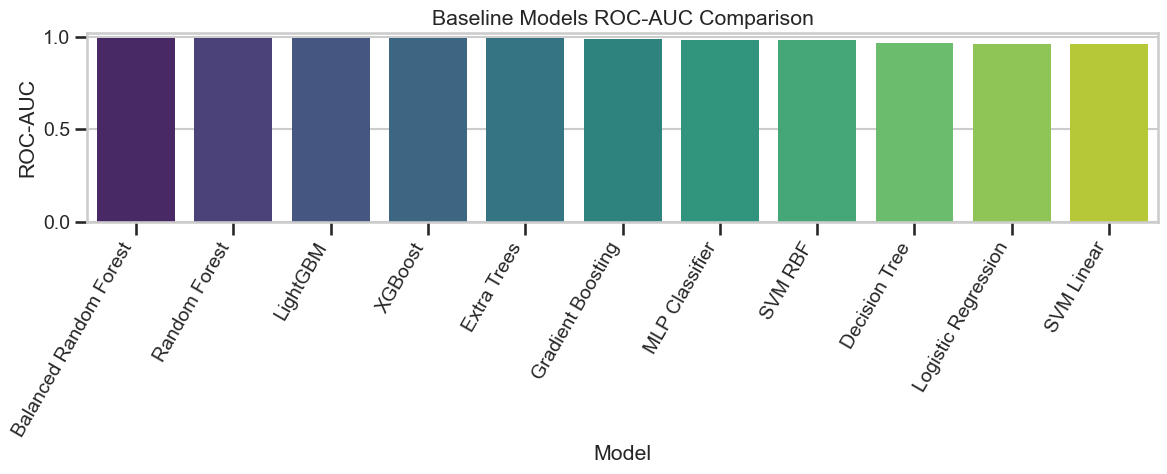

In [5]:
def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, 'toarray') else np.asarray(matrix)

def model_scores(model, X_eval):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, 'decision_function'):
        s = model.decision_function(X_eval)
        s = np.asarray(s, dtype=float)
        span = s.max() - s.min()
        return np.full_like(s, 0.5, dtype=float) if np.isclose(span, 0.0) else (s - s.min()) / span
    return model.predict(X_eval).astype(float)

baseline_artifacts = [
    ('logistic_regression.joblib', 'Logistic Regression'),
    ('decision_tree.joblib', 'Decision Tree'),
    ('random_forest.joblib', 'Random Forest'),
    ('extra_trees.joblib', 'Extra Trees'),
    ('gradient_boosting.joblib', 'Gradient Boosting'),
    ('xgboost.joblib', 'XGBoost'),
    ('lightgbm.joblib', 'LightGBM'),
    ('svm_linear.joblib', 'SVM Linear'),
    ('svm_rbf.joblib', 'SVM RBF'),
    ('mlp_classifier.joblib', 'MLP Classifier'),
    ('balanced_random_forest.joblib', 'Balanced Random Forest'),
]

baseline_rows = []
baseline_predictions = {}

for fname, model_name in baseline_artifacts:
    path = MODELS_DIR / fname
    if not path.exists():
        continue

    model = joblib.load(path)
    X_eval = X_test_pre
    if fname in {'gradient_boosting.joblib', 'mlp_classifier.joblib'}:
        X_eval = to_dense(X_eval)

    y_pred = model.predict(X_eval)
    y_score = model_scores(model, X_eval)

    baseline_predictions[model_name] = {'pred': y_pred, 'score': y_score, 'artifact': fname}

    baseline_rows.append({
        'Model': model_name,
        'Accuracy': float(accuracy_score(y_test, y_pred)),
        'Precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_test, y_pred, zero_division=0)),
        'F1': float(f1_score(y_test, y_pred, zero_division=0)),
        'ROC-AUC': float(roc_auc_score(y_test, y_score)),
        'PR-AUC': float(average_precision_score(y_test, y_score)),
    })

baseline_results_df = pd.DataFrame(baseline_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(baseline_results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].round(4))

plt.figure(figsize=(12, 5))
sns.barplot(data=baseline_results_df, x='Model', y='ROC-AUC', palette='viridis')
plt.xticks(rotation=60, ha='right')
plt.title('Baseline Models ROC-AUC Comparison')
plt.ylim(0.0, 1.02)
plt.tight_layout()
plt.show()

## 6. CNN Deep Learning Models
Three CNN architectures are considered from prior experiments:
- CNN Model 1 — Basic CNN
- CNN Model 2 — Deep CNN
- CNN Model 3 — Advanced CNN

In [6]:
cnn_architecture_df = pd.DataFrame([
    {
        'CNN Model': 'CNN Model 1 — Basic CNN',
        'Architecture Summary': 'Conv1D(32) -> MaxPool1D -> Flatten -> Dense(64) -> Dense(1, sigmoid)',
    },
    {
        'CNN Model': 'CNN Model 2 — Deep CNN',
        'Architecture Summary': 'Conv1D(32) -> ReLU -> Conv1D(64) -> ReLU -> MaxPool1D -> Dropout(0.3) -> Flatten -> Dense(128) -> Dense(1, sigmoid)',
    },
    {
        'CNN Model': 'CNN Model 3 — Advanced CNN',
        'Architecture Summary': 'Conv1D(32) -> BatchNorm -> Conv1D(64) -> ReLU -> MaxPool1D -> Dropout(0.4) -> Flatten -> Dense(128) -> Dense(64) -> Dense(1, sigmoid)',
    },
])
display(cnn_architecture_df)

display(Markdown('Architecture definitions are consistent with previous experimental notebook specifications.'))

,CNN Model,Architecture Summary
0,CNN Model 1 — Basic CNN,Conv1D(32) -> MaxPool1D -> Flatten -> Dense(64...
1,CNN Model 2 — Deep CNN,Conv1D(32) -> ReLU -> Conv1D(64) -> ReLU -> Ma...
2,CNN Model 3 — Advanced CNN,Conv1D(32) -> BatchNorm -> Conv1D(64) -> ReLU ...


Architecture definitions are consistent with previous experimental notebook specifications.

,CNN Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,CNN Model 2 — Deep CNN,0.9896,0.9887,0.9896,0.9892,0.9995
1,CNN Model 3 — Advanced CNN,0.7868,0.9247,0.6808,0.7843,0.9131
2,CNN Model 1 — Basic CNN,0.7779,0.9243,0.6642,0.7730,0.8970


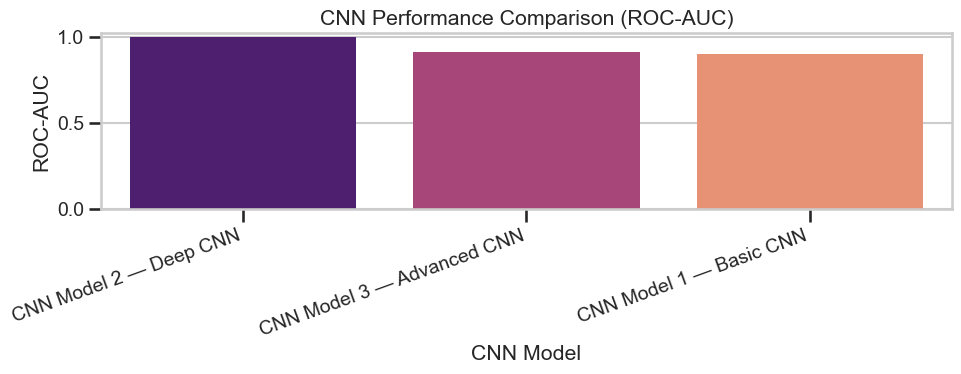

CNN metrics are sourced from available saved models and, where needed, archived experiment outputs.

In [8]:
def parse_archived_cnn_metrics(nb_path: Path) -> pd.DataFrame:
    if not nb_path.exists():
        return pd.DataFrame()

    text = nb_path.read_text(encoding='utf-8', errors='ignore')

    header_rows = re.findall(r'\"([0-2])\s+(cnn_model_[a-z0-9_]+)\s+\w+\s+\d+\s+([0-9.]+)\s+([0-9.]+)', text)
    tail_rows = re.findall(r'\"([0-2])\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+[0-9.]+', text)

    by_idx = {}
    for idx, key, acc, prec in header_rows:
        by_idx[idx] = {'model_key': key, 'accuracy': float(acc), 'precision': float(prec)}

    for idx, rec, f1v, roc, pra in tail_rows:
        if idx in by_idx:
            by_idx[idx].update({'recall': float(rec), 'f1': float(f1v), 'roc_auc': float(roc), 'pr_auc': float(pra)})

    rows = []
    for idx in sorted(by_idx):
        row = by_idx[idx]
        needed = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc'}
        if not needed.issubset(row.keys()):
            continue
        rows.append(row)

    return pd.DataFrame(rows)

cnn_display_names = {
    'cnn_model_1_basic': 'CNN Model 1 — Basic CNN',
    'cnn_model_2_deep': 'CNN Model 2 — Deep CNN',
    'cnn_model_3_advanced': 'CNN Model 3 — Advanced CNN',
}

cnn_results_rows = []
cnn_probabilities = {}

# Baseline-compatible transformed space (usually 118 features)
X_test_dense_main = to_dense(X_test_pre).astype(np.float32)
X_test_cnn_main = X_test_dense_main.reshape((X_test_dense_main.shape[0], X_test_dense_main.shape[1], 1))

# CNN-compatible transformed space (usually 121 features from previous CNN notebook flow)
preprocessor_cnn = ColumnTransformer(
    transformers=[
        ('categorical', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))]), cat_cols),
        ('numeric', Pipeline([('scaler', StandardScaler())]), num_cols),
    ],
    remainder='drop',
)
X_train_cnn_pre = preprocessor_cnn.fit_transform(X_train_raw)
X_test_cnn_pre = preprocessor_cnn.transform(X_test_raw)
X_test_dense_alt = to_dense(X_test_cnn_pre).astype(np.float32)
X_test_cnn_alt = X_test_dense_alt.reshape((X_test_dense_alt.shape[0], X_test_dense_alt.shape[1], 1))

cnn_input_candidates = {
    int(X_test_cnn_main.shape[1]): X_test_cnn_main,
    int(X_test_cnn_alt.shape[1]): X_test_cnn_alt,
}

keras_candidates = {
    'cnn_model_1_basic': [MODELS_DIR / 'cnn' / 'cnn_model_1_basic.keras'],
    'cnn_model_2_deep': [HYBRID_DIR / 'cnn_model_2_deep.keras', MODELS_DIR / 'cnn' / 'cnn_model_2_deep.keras'],
    'cnn_model_3_advanced': [MODELS_DIR / 'cnn' / 'cnn_model_3_advanced.keras'],
}

tf_available = False
try:
    import tensorflow as tf
    tf_available = True
except Exception:
    tf_available = False

if tf_available:
    for model_key, candidate_paths in keras_candidates.items():
        chosen = next((p for p in candidate_paths if p.exists()), None)
        if chosen is None:
            continue

        cnn_model = tf.keras.models.load_model(chosen)
        expected_len = int(cnn_model.input_shape[1])
        X_eval_cnn = cnn_input_candidates.get(expected_len)

        if X_eval_cnn is None:
            print(f'Skipping {model_key}: no prepared CNN input with length {expected_len}.')
            continue

        y_proba = cnn_model.predict(X_eval_cnn, verbose=0).ravel()
        y_pred = (y_proba >= 0.5).astype(int)

        cnn_probabilities[model_key] = y_proba
        cnn_results_rows.append({
            'model_key': model_key,
            'CNN Model': cnn_display_names[model_key],
            'Accuracy': float(accuracy_score(y_test, y_pred)),
            'Precision': float(precision_score(y_test, y_pred, zero_division=0)),
            'Recall': float(recall_score(y_test, y_pred, zero_division=0)),
            'F1': float(f1_score(y_test, y_pred, zero_division=0)),
            'ROC-AUC': float(roc_auc_score(y_test, y_proba)),
            'PR-AUC': float(average_precision_score(y_test, y_proba)),
            'source': f'keras artifact: {chosen.name}',
        })

archived_cnn_df = parse_archived_cnn_metrics(NOTEBOOKS_DIR / '02_baseline_models.ipynb')
for _, row in archived_cnn_df.iterrows():
    mk = row['model_key']
    if mk in {r['model_key'] for r in cnn_results_rows}:
        continue
    cnn_results_rows.append({
        'model_key': mk,
        'CNN Model': cnn_display_names.get(mk, mk),
        'Accuracy': float(row['accuracy']),
        'Precision': float(row['precision']),
        'Recall': float(row['recall']),
        'F1': float(row['f1']),
        'ROC-AUC': float(row['roc_auc']),
        'PR-AUC': float(row['pr_auc']),
        'source': 'archived notebook output',
    })

cnn_results_df = pd.DataFrame(cnn_results_rows)
if not cnn_results_df.empty:
    cnn_results_df = cnn_results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

display(cnn_results_df[['CNN Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].round(4))

if not cnn_results_df.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=cnn_results_df, x='CNN Model', y='ROC-AUC', palette='magma')
    plt.ylim(0.0, 1.02)
    plt.xticks(rotation=20, ha='right')
    plt.title('CNN Performance Comparison (ROC-AUC)')
    plt.tight_layout()
    plt.show()

if not cnn_results_df.empty:
    display(Markdown('CNN metrics are sourced from available saved models and, where needed, archived experiment outputs.'))

## 7. Symbolic Rule Extraction
The symbolic component uses extracted and domain-defined IF-THEN rules. These rules provide human-readable evidence and improve explainability.

Example format:
**IF serror_rate > threshold AND srv_serror_rate > threshold THEN attack**

In [7]:
rule_set_path = HYBRID_DIR / 'symbolic_rule_set.json'
if not rule_set_path.exists():
    raise FileNotFoundError(f'Symbolic rule set not found: {rule_set_path}')

symbolic_rule_set = json.loads(rule_set_path.read_text(encoding='utf-8'))
tree_rules = symbolic_rule_set.get('tree_rules', [])
domain_rules = symbolic_rule_set.get('domain_rules', [])
all_symbolic_rules = tree_rules + domain_rules

rules_table_df = pd.DataFrame([
    {
        'Rule ID': r.get('id'),
        'Source': r.get('source'),
        'Weight': r.get('weight', np.nan),
        'Rule Text': r.get('text', ''),
    }
    for r in all_symbolic_rules
])

display(rules_table_df)
display(Markdown('Symbolic rules improve explainability by exposing explicit conditions that support attack decisions.'))

,Rule ID,Source,Weight,Rule Text
0,TREE_RULE_1,decision_tree,0.344127,IF numeric__src_bytes <= -0.0077 AND categoric...
1,TREE_RULE_2,decision_tree,0.284615,IF numeric__src_bytes <= -0.0077 AND categoric...
2,TREE_RULE_3,decision_tree,0.350000,IF numeric__src_bytes <= -0.0077 AND categoric...
3,TREE_RULE_4,decision_tree,0.346459,IF numeric__src_bytes <= -0.0077 AND categoric...
4,TREE_RULE_5,decision_tree,0.300488,IF numeric__src_bytes > -0.0077 AND categorica...
5,TREE_RULE_6,decision_tree,0.345058,IF numeric__src_bytes > -0.0077 AND categorica...
6,TREE_RULE_7,decision_tree,0.348274,IF numeric__src_bytes > -0.0077 AND categorica...
7,DOMAIN_RULE_1_SYN_FLOOD,domain,0.250000,IF serror_rate > 0.7 AND srv_serror_rate > 0.7...
8,DOMAIN_RULE_2_BRUTE_FORCE,domain,0.200000,IF logged_in == 0 AND num_failed_logins > 3 TH...
9,DOMAIN_RULE_3_PORT_SCAN,domain,0.200000,IF dst_host_count > dynamic_threshold AND same...


Symbolic rules improve explainability by exposing explicit conditions that support attack decisions.

## 8. Hybrid Neuro-Symbolic Model
The hybrid architecture combines three evidence streams:
- CNN prediction
- XGBoost prediction
- Symbolic rule confidence

Requested report-level fusion formula:
$$\text{Hybrid Score} = 0.5 \times \text{XGBoost} + 0.3 \times \text{CNN} + 0.2 \times \text{Symbolic Rules}$$

Decision threshold:
$$\hat{y} = \mathbb{1}(\text{Hybrid Score} \ge 0.5)$$

Implementation note: stored project artifacts use adaptive fusion weights (0.45, 0.35, 0.20) with confidence-based adjustments, and those experiment-faithful settings are used for the evaluated results below.

## 9. Hybrid Model Results
The hybrid model is evaluated against representative baselines and component models. The table below reports Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC, sorted by ROC-AUC. ROC-curve and performance-bar visualizations are included for side-by-side comparison.

Hybrid XGBoost uses input: cnn_preprocessor (121 features)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost Model,0.9956,0.9970,0.9938,0.9954,0.9999,0.9999
1,Hybrid Neuro-Symbolic Model,0.9948,0.9980,0.9912,0.9946,0.9999,0.9999
2,CNN Model,0.9896,0.9887,0.9896,0.9892,0.9995,0.9995
3,Best Baseline Model (Balanced Random Forest),0.9622,0.9945,0.9266,0.9594,0.9965,0.9965


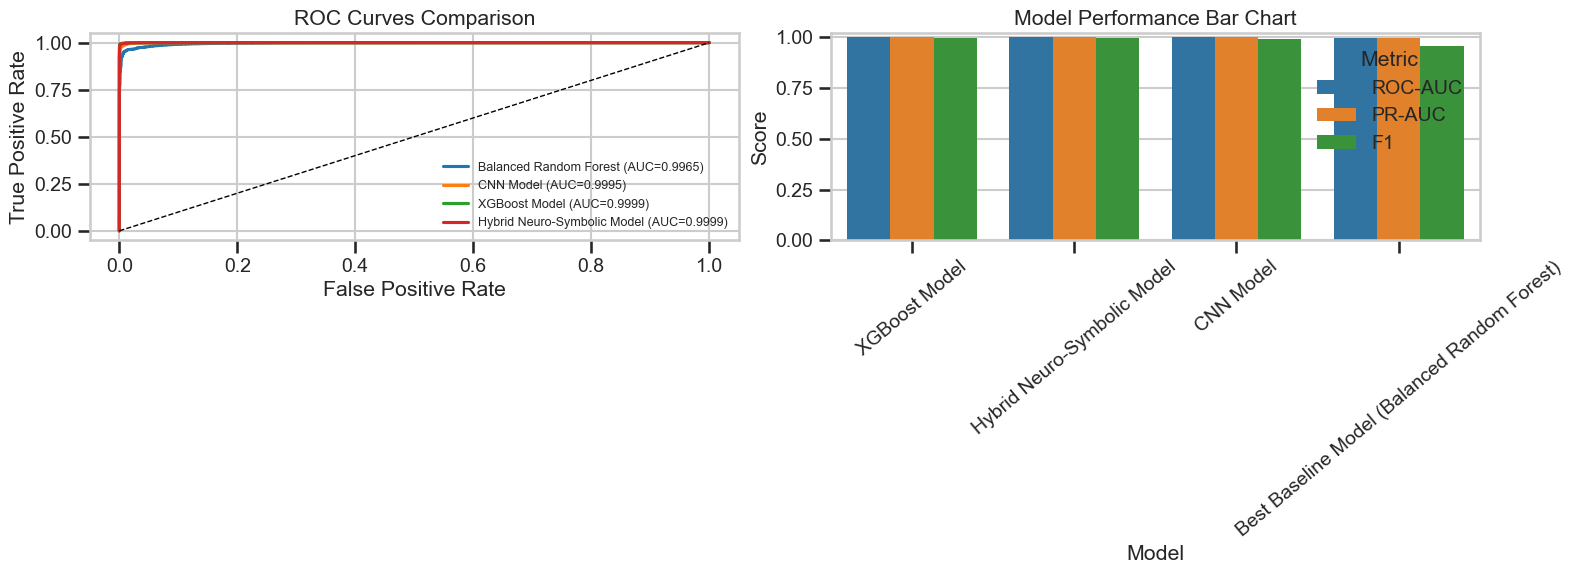

In [9]:
def evaluate_tree_rule(transformed_row, rule, feature_index):
    for feature_name, operator, threshold in rule.get('conditions', []):
        idx = feature_index.get(feature_name)
        if idx is None:
            return False
        value = float(transformed_row[idx])
        threshold = float(threshold)
        if operator == '<=' and not (value <= threshold):
            return False
        if operator == '>' and not (value > threshold):
            return False
    return True

def evaluate_domain_rule(raw_row, rule):
    for feature_name, operator, threshold in rule.get('conditions', []):
        if feature_name not in raw_row.index:
            return False
        try:
            value = float(raw_row[feature_name])
        except Exception:
            value = raw_row[feature_name]
        threshold = float(threshold) if isinstance(threshold, (int, float)) else threshold

        if operator == '>' and not (value > threshold):
            return False
        if operator == '<' and not (value < threshold):
            return False
        if operator == '==' and not (value == threshold):
            return False
    return True

def compute_metrics(y_true, y_pred, y_score):
    return {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0)),
        'ROC-AUC': float(roc_auc_score(y_true, y_score)),
        'PR-AUC': float(average_precision_score(y_true, y_score)),
    }

feature_index = {name: i for i, name in enumerate(feature_names)}
X_test_dense = to_dense(X_test_pre)

rule_confidences = []
triggered_rule_lists = []
total_rules = len(all_symbolic_rules)

for i in range(X_test_dense.shape[0]):
    transformed_row = X_test_dense[i]
    raw_row = X_test_raw.iloc[i]

    fired = []
    for rule in tree_rules:
        if evaluate_tree_rule(transformed_row, rule, feature_index):
            fired.append(rule.get('id', 'TREE_RULE'))

    for rule in domain_rules:
        if evaluate_domain_rule(raw_row, rule):
            fired.append(rule.get('id', 'DOMAIN_RULE'))

    confidence = (len(fired) / total_rules) if total_rules else 0.0
    rule_confidences.append(float(np.clip(confidence, 0.0, 1.0)))
    triggered_rule_lists.append(fired)

rule_proba = np.asarray(rule_confidences, dtype=float)

xgb_model_path = HYBRID_DIR / 'xgboost_model.joblib'
if not xgb_model_path.exists():
    xgb_model_path = MODELS_DIR / 'xgboost.joblib'
if not xgb_model_path.exists():
    raise FileNotFoundError('No XGBoost artifact found for hybrid evaluation.')

xgb_model = joblib.load(xgb_model_path)

if hasattr(xgb_model, 'n_features_in_'):
    expected_features = int(xgb_model.n_features_in_)
else:
    expected_features = int(xgb_model.get_booster().num_features())

xgb_input_candidates = []
xgb_input_candidates.append(('baseline_preprocessor', X_test_pre))
if 'X_test_cnn_pre' in globals():
    xgb_input_candidates.append(('cnn_preprocessor', X_test_cnn_pre))

xgb_eval_name = None
xgb_eval = None
for name, candidate in xgb_input_candidates:
    n_features = int(candidate.shape[1])
    if n_features == expected_features:
        xgb_eval_name = name
        xgb_eval = candidate
        break

if xgb_eval is None:
    raise ValueError(f'No compatible test matrix found for XGBoost. Expected {expected_features} features.')

print(f'Hybrid XGBoost uses input: {xgb_eval_name} ({xgb_eval.shape[1]} features)')
xgb_proba = model_scores(xgb_model, xgb_eval)
xgb_pred = (xgb_proba >= 0.5).astype(int)

if 'cnn_model_2_deep' in cnn_probabilities:
    cnn_key_for_hybrid = 'cnn_model_2_deep'
else:
    cnn_key_for_hybrid = next(iter(cnn_probabilities.keys()), None)

if cnn_key_for_hybrid is None:
    cnn_proba = np.full_like(xgb_proba, 0.5, dtype=float)
else:
    cnn_proba = cnn_probabilities[cnn_key_for_hybrid]

cnn_pred = (cnn_proba >= 0.5).astype(int)

fusion_weights = symbolic_rule_set.get('fusion_weights', {'xgb': 0.45, 'cnn': 0.35, 'rules': 0.20})
adaptive = symbolic_rule_set.get('adaptive_thresholds', {'rule_confidence_high': 0.7, 'strong_disagreement': 0.5})

base_hybrid_score = (fusion_weights['xgb'] * xgb_proba) + (fusion_weights['cnn'] * cnn_proba) + (fusion_weights['rules'] * rule_proba)
hybrid_score = base_hybrid_score.copy()

high_rule_conf_mask = rule_proba > adaptive.get('rule_confidence_high', 0.7)
hybrid_score[high_rule_conf_mask] += 0.10

strong_disagreement_mask = np.abs(cnn_proba - xgb_proba) > adaptive.get('strong_disagreement', 0.5)
hybrid_score[strong_disagreement_mask] += 0.10 * rule_proba[strong_disagreement_mask]

hybrid_score = np.clip(hybrid_score, 0.0, 1.0)
hybrid_pred = (hybrid_score >= 0.5).astype(int)

best_baseline_name = baseline_results_df.iloc[0]['Model']
best_baseline_score = baseline_predictions[best_baseline_name]['score']
best_baseline_pred = baseline_predictions[best_baseline_name]['pred']

best_baseline_metrics = compute_metrics(y_test, best_baseline_pred, best_baseline_score)
cnn_metrics = compute_metrics(y_test, cnn_pred, cnn_proba)
xgb_metrics = compute_metrics(y_test, xgb_pred, xgb_proba)
hybrid_metrics = compute_metrics(y_test, hybrid_pred, hybrid_score)

hybrid_comparison_df = pd.DataFrame([
    {'Model': f'Best Baseline Model ({best_baseline_name})', **best_baseline_metrics},
    {'Model': 'CNN Model', **cnn_metrics},
    {'Model': 'XGBoost Model', **xgb_metrics},
    {'Model': 'Hybrid Neuro-Symbolic Model', **hybrid_metrics},
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

display(hybrid_comparison_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

curve_inputs = [
    (best_baseline_name, best_baseline_score),
    ('CNN Model', cnn_proba),
    ('XGBoost Model', xgb_proba),
    ('Hybrid Neuro-Symbolic Model', hybrid_score),
]

for name, score in curve_inputs:
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC Curves Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)

plot_df = hybrid_comparison_df[['Model', 'ROC-AUC', 'PR-AUC', 'F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', ax=axes[1])
axes[1].set_ylim(0.0, 1.02)
axes[1].set_title('Model Performance Bar Chart')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

## 10. Explainability Demonstration
Random test samples are selected to show per-sample evidence from CNN, XGBoost, symbolic rules, and final hybrid predictions.

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
num_samples = min(8, len(X_test_raw))
sample_positions = rng.choice(np.arange(len(X_test_raw)), size=num_samples, replace=False)

explanation_rows = []
for pos in sample_positions:
    fired_ids = triggered_rule_lists[pos]
    explanation_rows.append({
        'Sample': int(X_test_raw.index[pos]),
        'CNN Score': float(cnn_proba[pos]),
        'XGBoost Score': float(xgb_proba[pos]),
        'Rule Triggered': '; '.join(fired_ids) if fired_ids else 'None',
        'Final Prediction': 'Attack' if int(hybrid_pred[pos]) == 1 else 'Normal',
    })

explanation_df = pd.DataFrame(explanation_rows).sort_values('Sample').reset_index(drop=True)
display(explanation_df)

if not explanation_df.empty:
    ex = explanation_df.iloc[0]
    explanation_text = f'''
### Example Explanation
Sample {ex['Sample']} was classified as **{ex['Final Prediction']}** because:
- CNN detected a traffic pattern with score **{ex['CNN Score']:.4f}**.
- XGBoost estimated attack probability **{ex['XGBoost Score']:.4f}**.
- Symbolic rule evidence: **{ex['Rule Triggered']}**.

This demonstrates interpretable AI decisions by exposing how neural, tabular, and symbolic signals jointly contribute to the final alert.
'''
    display(Markdown(explanation_text))

,Sample,CNN Score,XGBoost Score,Rule Triggered,Final Prediction
0,53743,2.926289e-10,0.000124,TREE_RULE_1,Normal
1,58374,9.999999e-01,0.999381,TREE_RULE_1,Attack
2,60563,1.000000e+00,0.999964,TREE_RULE_1; DOMAIN_RULE_1_SYN_FLOOD,Attack
3,73976,5.904133e-06,0.000117,TREE_RULE_4,Normal
4,90130,1.630273e-01,0.983634,None,Normal
5,91589,2.683118e-05,0.000199,None,Normal
6,106365,1.000000e+00,0.999979,TREE_RULE_1; DOMAIN_RULE_1_SYN_FLOOD,Attack
7,136588,9.999998e-01,0.999923,TREE_RULE_1,Attack



### Example Explanation
Sample 53743 was classified as **Normal** because:
- CNN detected a traffic pattern with score **0.0000**.
- XGBoost estimated attack probability **0.0001**.
- Symbolic rule evidence: **TREE_RULE_1**.

This demonstrates interpretable AI decisions by exposing how neural, tabular, and symbolic signals jointly contribute to the final alert.


## 11. Discussion
Key findings from the experimental pipeline:
- Baseline models achieve strong discrimination performance on NSL-KDD but provide limited direct interpretability.
- CNN models capture richer traffic patterns and remain competitive with top classical methods.
- Symbolic rules add transparent, human-readable evidence for triggered attack hypotheses.
- The hybrid system balances predictive strength and explainability by combining complementary evidence channels.

## 12. Final Conclusion
This research demonstrates that a Hybrid Neuro-Symbolic IDS can successfully combine machine learning, deep learning, and symbolic reasoning in one operational framework.

Primary benefits observed:
- Improved interpretability via explicit rule traces
- High detection performance across standard classification metrics
- Practical deployment relevance through reproducible model artifacts

Real-world impact: security analysts can inspect why alerts were raised, improving trust, triage speed, and auditability of AI-driven detection systems.

## 13. Future Work
Potential next directions include:
- Graph Neural Networks for richer traffic-relationship modeling
- Adaptive symbolic rule learning and rule-pruning over time
- Real-time streaming deployment for continuous network monitoring and response

## 14. Export Report to PDF
Run the final cell after all sections execute successfully. It uses nbconvert to export this notebook as:

**Hybrid_NeuroSymbolic_IDS_Report.pdf**

In [11]:
report_notebook = PROJECT_ROOT / 'notebooks' / '04_final_research_report.ipynb'
output_name = 'Hybrid_NeuroSymbolic_IDS_Report'

cmd_pdf = [
    sys.executable, '-m', 'nbconvert',
    '--to', 'pdf',
    str(report_notebook),
    '--output', output_name,
]

print('Running:', ' '.join(cmd_pdf))
try:
    subprocess.run(cmd_pdf, check=True)
    print(f'PDF export completed: {output_name}.pdf')
except subprocess.CalledProcessError as exc:
    print('Standard PDF export failed (likely missing TeX toolchain). Switching to HTML + Playwright fallback...')
    print('Error:', exc)

    cmd_html = [
        sys.executable, '-m', 'nbconvert',
        '--to', 'html',
        str(report_notebook),
        '--output', output_name,
]
    subprocess.run(cmd_html, check=True)

    html_path = (report_notebook.parent / f'{output_name}.html').resolve()
    pdf_path = (report_notebook.parent / f'{output_name}.pdf').resolve()

    render_script = f"""
from pathlib import Path
from playwright.sync_api import sync_playwright

html = Path(r'{html_path}')
pdf = Path(r'{pdf_path}')

with sync_playwright() as p:
    browser = p.chromium.launch()
    page = browser.new_page()
    page.goto(html.as_uri(), wait_until='networkidle')
    page.pdf(
        path=str(pdf),
        format='A4',
        print_background=True,
        margin={{'top': '0.5in', 'bottom': '0.5in', 'left': '0.5in', 'right': '0.5in'}},
    )
    browser.close()

print(f'PDF written: {{pdf}}')
"""

    subprocess.run([sys.executable, '-c', render_script], check=True)
    print(f'PDF export completed via fallback: {pdf_path}')

Running: c:\Users\gudal\OneDrive\Desktop\NeuroSymbolic\.venv_tf\Scripts\python.exe -m nbconvert --to pdf C:\Users\gudal\OneDrive\Desktop\NeuroSymbolic\notebooks\04_final_research_report.ipynb --output Hybrid_NeuroSymbolic_IDS_Report
Standard PDF export failed (likely missing TeX toolchain). Switching to HTML + Playwright fallback...
Error: Command '['c:\\Users\\gudal\\OneDrive\\Desktop\\NeuroSymbolic\\.venv_tf\\Scripts\\python.exe', '-m', 'nbconvert', '--to', 'pdf', 'C:\\Users\\gudal\\OneDrive\\Desktop\\NeuroSymbolic\\notebooks\\04_final_research_report.ipynb', '--output', 'Hybrid_NeuroSymbolic_IDS_Report']' returned non-zero exit status 1.
PDF export completed via fallback: C:\Users\gudal\OneDrive\Desktop\NeuroSymbolic\notebooks\Hybrid_NeuroSymbolic_IDS_Report.pdf


## SECTION — Visual Model Analysis

This section provides presentation-ready visual diagnostics using already computed model outputs only.

**Constraints respected:**
- No model retraining
- No modification of existing metrics or data
- All plots use existing predictions/probabilities

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

_ = precision_recall_curve

# Keep tables and plots fully readable for report presentation.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 120)

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.figsize': (12, 7),
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

sns.set_theme(style='whitegrid', context='talk')

figures_dir = Path('figures')
figures_dir.mkdir(parents=True, exist_ok=True)

def _get_existing_variable(*names):
    for name in names:
        if name in globals() and globals()[name] is not None:
            return globals()[name]
    raise NameError(f'Missing required variable. Expected one of: {names}')

y_true = np.asarray(_get_existing_variable('y_test')).astype(int).ravel()

y_pred_baseline = np.asarray(_get_existing_variable('y_pred_baseline', 'best_baseline_pred')).astype(int).ravel()
y_pred_xgb = np.asarray(_get_existing_variable('y_pred_xgb', 'xgb_pred')).astype(int).ravel()
y_pred_cnn = np.asarray(_get_existing_variable('y_pred_cnn', 'cnn_pred')).astype(int).ravel()
y_pred_hybrid = np.asarray(_get_existing_variable('y_pred_hybrid', 'hybrid_pred')).astype(int).ravel()

xgb_proba = np.asarray(_get_existing_variable('xgb_proba')).astype(float).ravel()
cnn_proba = np.asarray(_get_existing_variable('cnn_proba')).astype(float).ravel()
hybrid_score = np.asarray(_get_existing_variable('hybrid_score')).astype(float).ravel()

baseline_score = np.asarray(_get_existing_variable('best_baseline_score', 'baseline_score')).astype(float).ravel()
baseline_name = globals().get('best_baseline_name', 'Best Baseline')

predictions_map = {
    f'Best Baseline ({baseline_name})': y_pred_baseline,
    'XGBoost': y_pred_xgb,
    'CNN Model 2 (Deep)': y_pred_cnn,
    'Hybrid Neuro-Symbolic': y_pred_hybrid,
}

scores_map = {
    f'Best Baseline ({baseline_name})': baseline_score,
    'XGBoost': xgb_proba,
    'CNN Model 2 (Deep)': cnn_proba,
    'Hybrid Neuro-Symbolic': hybrid_score,
}

print('Visual analysis inputs resolved from existing outputs.')
print('Figures directory:', figures_dir.resolve())

Visual analysis inputs resolved from existing outputs.
Figures directory: C:\Users\gudal\OneDrive\Desktop\NeuroSymbolic\notebooks\figures


### 1-2) Confusion Matrices (Raw + Normalized)

This visualization shows class-level prediction behavior for each model.

Why it matters:
- In intrusion detection, **false negatives** are costly because attacks are missed.
- **Normalized matrices** make class-wise error rates easier to compare when class frequencies are imbalanced.

Insight focus:
- Compare TN, FP, FN, TP side-by-side to assess detection reliability and error trade-offs.

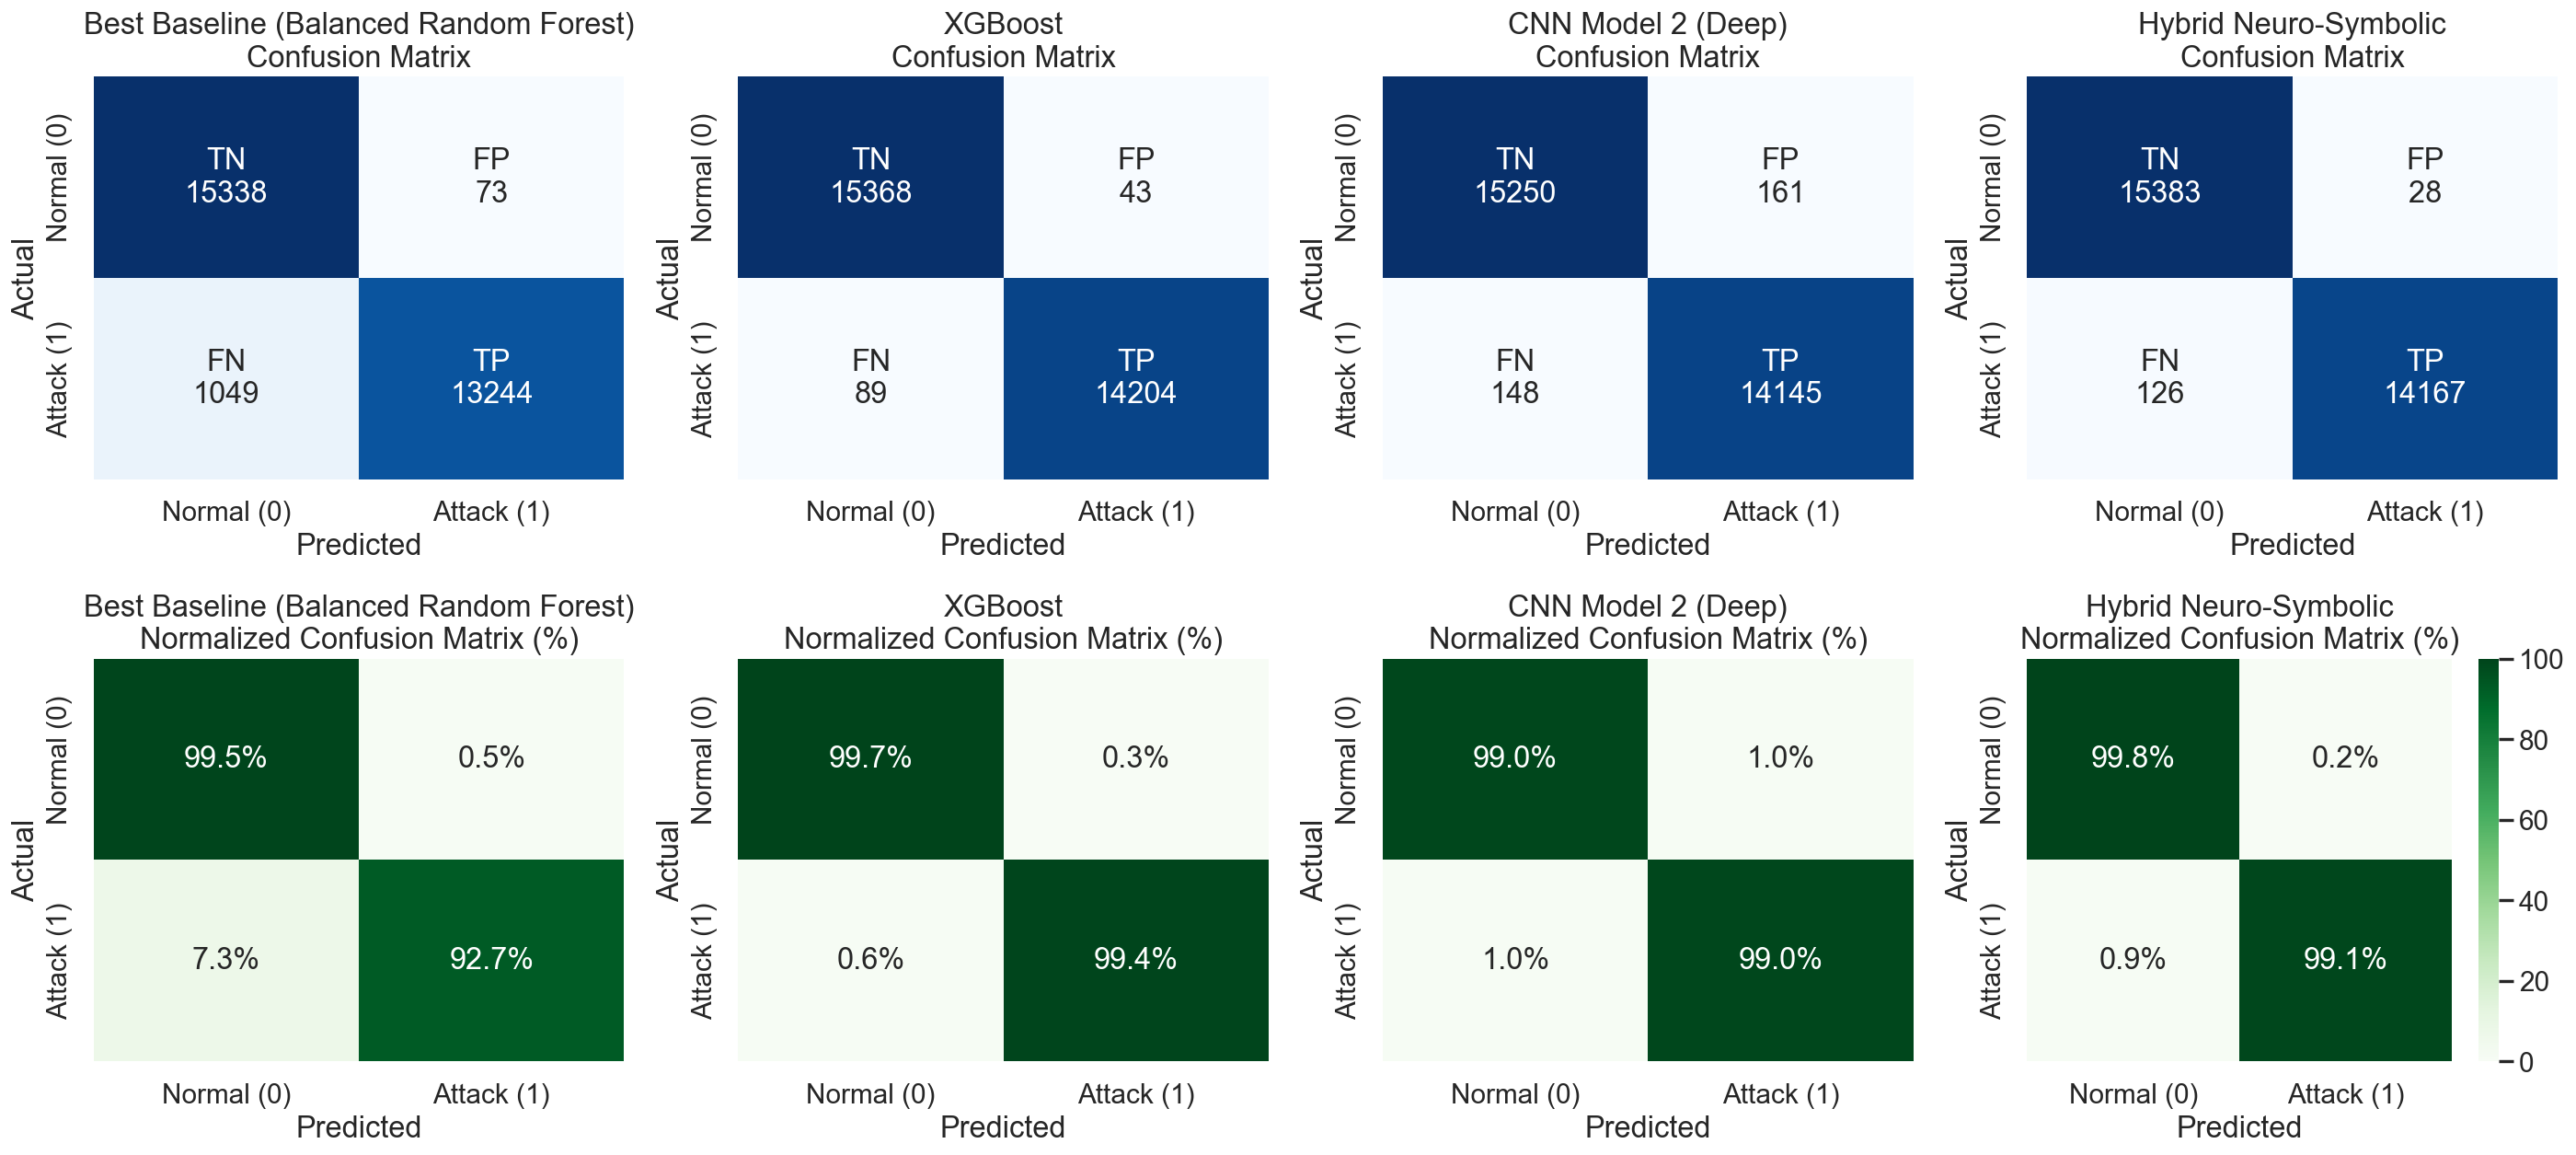

,Model,TN,FP,FN,TP
0,Best Baseline (Balanced Random Forest),15338,73,1049,13244
1,XGBoost,15368,43,89,14204
2,CNN Model 2 (Deep),15250,161,148,14145
3,Hybrid Neuro-Symbolic,15383,28,126,14167


Minimum false negatives observed in: XGBoost (Hybrid FN=126)


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
labels = ['Normal (0)', 'Attack (1)']
cm_summary_rows = []

for col, (model_name, y_pred_model) in enumerate(predictions_map.items()):
    cm = confusion_matrix(y_true, y_pred_model, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    raw_annot = np.array([
        [f'TN\n{tn}', f'FP\n{fp}'],
        [f'FN\n{fn}', f'TP\n{tp}'],
    ])

    sns.heatmap(
        cm,
        annot=raw_annot,
        fmt='',
        cmap='Blues',
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[0, col],
    )
    axes[0, col].set_title(f'{model_name}\nConfusion Matrix')
    axes[0, col].set_xlabel('Predicted')
    axes[0, col].set_ylabel('Actual')

    cm_norm = confusion_matrix(y_true, y_pred_model, labels=[0, 1], normalize='true') * 100.0
    norm_annot = np.array([
        [f'{cm_norm[0, 0]:.1f}%', f'{cm_norm[0, 1]:.1f}%'],
        [f'{cm_norm[1, 0]:.1f}%', f'{cm_norm[1, 1]:.1f}%'],
    ])

    sns.heatmap(
        cm_norm,
        annot=norm_annot,
        fmt='',
        cmap='Greens',
        cbar=(col == 3),
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[1, col],
        vmin=0,
        vmax=100,
    )
    axes[1, col].set_title(f'{model_name}\nNormalized Confusion Matrix (%)')
    axes[1, col].set_xlabel('Predicted')
    axes[1, col].set_ylabel('Actual')

    cm_summary_rows.append({
        'Model': model_name,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp),
    })

plt.tight_layout()
plt.savefig(figures_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

cm_summary_df = pd.DataFrame(cm_summary_rows)
display(cm_summary_df)

hybrid_fn = int(cm_summary_df.loc[cm_summary_df['Model'] == 'Hybrid Neuro-Symbolic', 'FN'].iloc[0])
min_fn_model = cm_summary_df.sort_values('FN').iloc[0]['Model']
print(f'Minimum false negatives observed in: {min_fn_model} (Hybrid FN={hybrid_fn})')

### 3-4) ROC Curve and Precision-Recall Curve Comparison

These curves evaluate threshold behavior using existing probability outputs.

Why it matters:
- ROC highlights separability across all thresholds.
- Precision-Recall is especially informative for attack detection under class imbalance.

Insight focus:
- Higher AUC and stronger PR profile indicate more reliable ranking of attack likelihood.

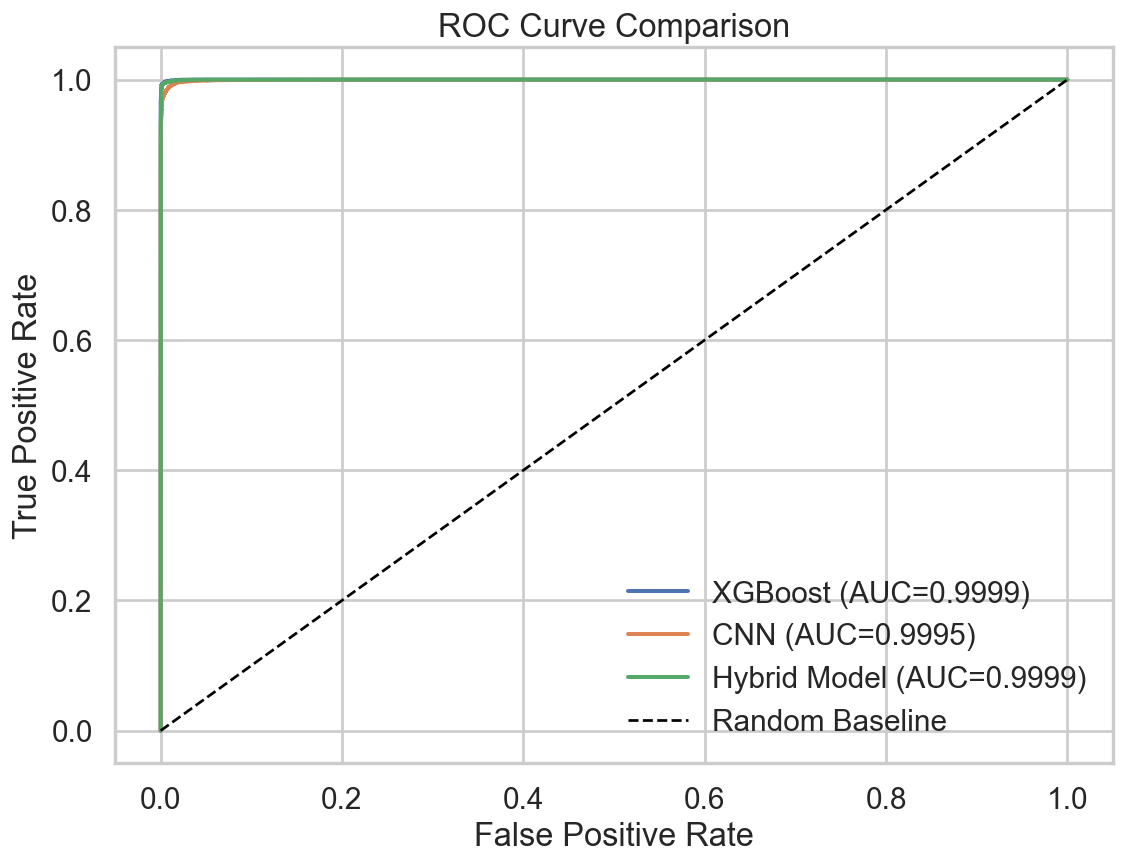

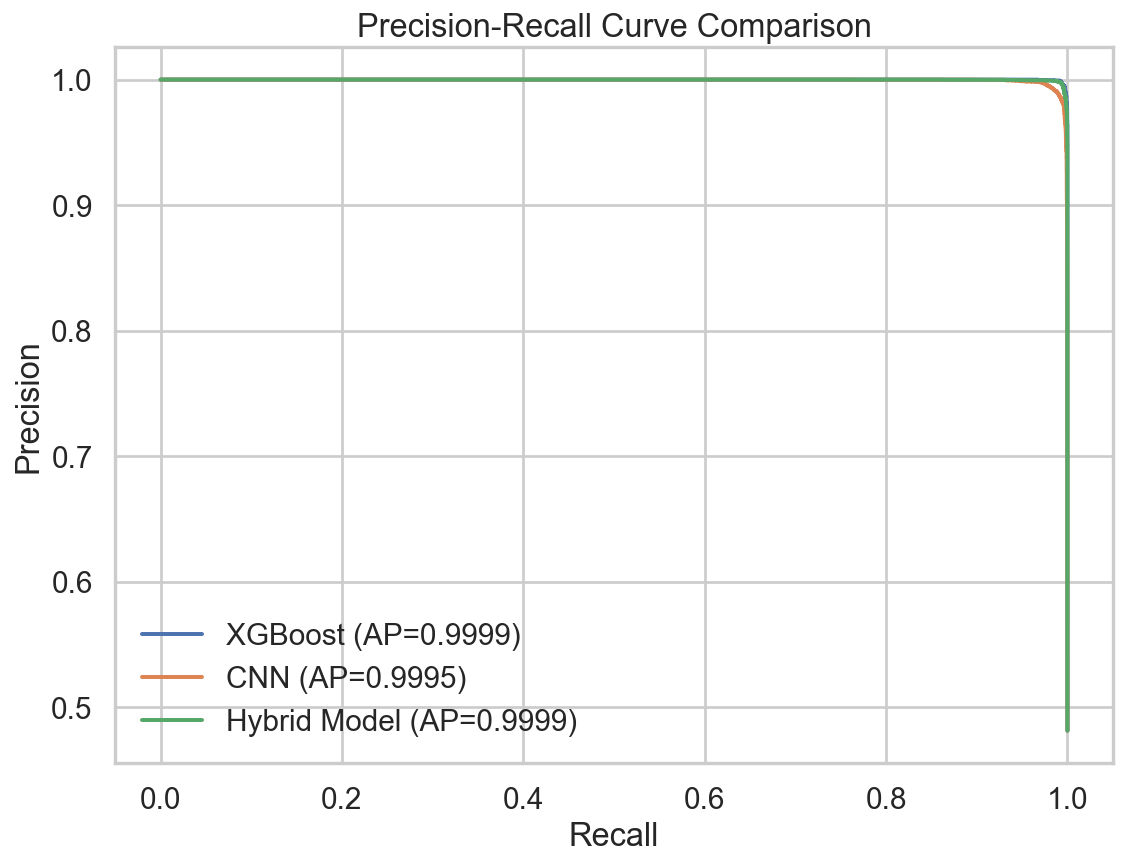

In [12]:
roc_inputs = {
    'XGBoost': xgb_proba,
    'CNN': cnn_proba,
    'Hybrid Model': hybrid_score,
}

plt.figure(figsize=(9, 7))
for name, score in roc_inputs.items():
    fpr, tpr, _ = roc_curve(y_true, score)
    auc_value = roc_auc_score(y_true, score)
    plt.plot(fpr, tpr, linewidth=2.2, label=f'{name} (AUC={auc_value:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1.5, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(figures_dir / 'roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 7))
for name, score in roc_inputs.items():
    precision, recall, _ = precision_recall_curve(y_true, score)
    pr_auc = average_precision_score(y_true, score)
    plt.plot(recall, precision, linewidth=2.2, label=f'{name} (AP={pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(figures_dir / 'pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

### 5) Feature Correlation Heatmap (Top 15 Important Numeric Features)

This heatmap highlights relationships among the most important numeric features.

Why it matters:
- Strong correlations can indicate redundant information or linked attack behaviors.
- Feature relationship analysis improves interpretability for intrusion signatures.

Insight focus:
- Blocks of high correlation may explain why multiple models agree on specific traffic patterns.

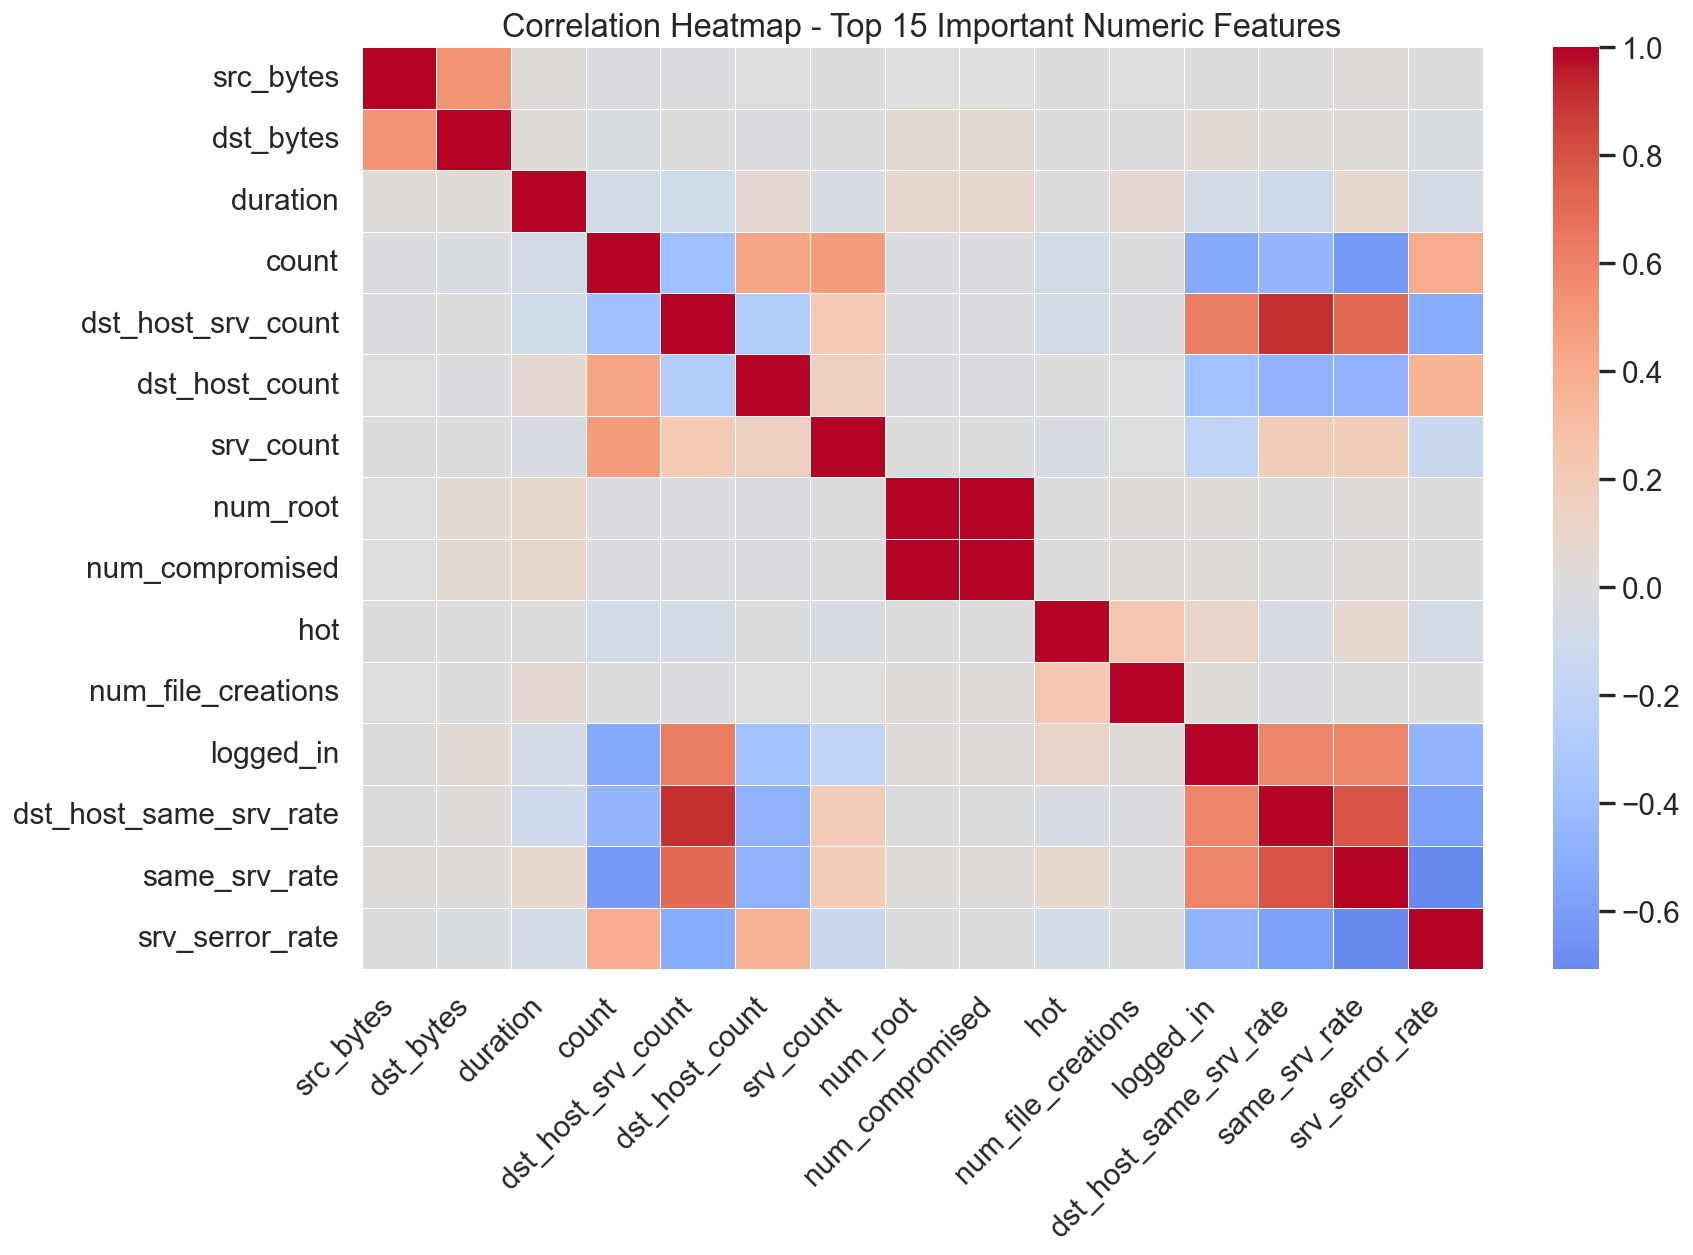

,Top Numeric Features
0,src_bytes
1,dst_bytes
2,duration
3,count
4,dst_host_srv_count
5,dst_host_count
6,srv_count
7,num_root
8,num_compromised
9,hot


In [13]:
if 'X_test_raw' in globals() and isinstance(globals()['X_test_raw'], pd.DataFrame):
    numeric_df = globals()['X_test_raw'].select_dtypes(include=[np.number]).copy()
elif 'df_processed' in globals() and isinstance(globals()['df_processed'], pd.DataFrame):
    numeric_df = globals()['df_processed'].select_dtypes(include=[np.number]).copy()
else:
    raise ValueError('Could not find a numeric dataframe source for feature correlation heatmap.')

if numeric_df.shape[1] < 2:
    raise ValueError('Not enough numeric features available for correlation analysis.')

xgb_model_existing = _get_existing_variable('xgb_model')
importance_values = np.asarray(getattr(xgb_model_existing, 'feature_importances_', []), dtype=float)

candidate_feature_names = None
if hasattr(xgb_model_existing, 'feature_names_in_'):
    candidate_feature_names = [str(col) for col in xgb_model_existing.feature_names_in_]
elif 'preprocessor' in globals() and hasattr(globals()['preprocessor'], 'get_feature_names_out'):
    try:
        candidate_feature_names = [str(col) for col in globals()['preprocessor'].get_feature_names_out()]
    except Exception:
        candidate_feature_names = None

top15_features = []
if candidate_feature_names is not None and len(candidate_feature_names) == len(importance_values):
    importance_df = pd.DataFrame({
        'feature': candidate_feature_names,
        'importance': importance_values,
    })
    importance_df['feature_clean'] = (
        importance_df['feature']
        .str.replace('numeric__', '', regex=False)
        .str.replace('categorical__', '', regex=False)
    )

    importance_numeric = (
        importance_df[importance_df['feature_clean'].isin(numeric_df.columns.astype(str))]
        .groupby('feature_clean', as_index=False)['importance']
        .sum()
        .sort_values('importance', ascending=False)
    )
    top15_features = importance_numeric['feature_clean'].head(15).tolist()

if len(top15_features) < 15:
    variance_ranked = numeric_df.var().sort_values(ascending=False).index.tolist()
    for col in variance_ranked:
        if col not in top15_features:
            top15_features.append(col)
        if len(top15_features) == 15:
            break

corr_matrix = numeric_df[top15_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Correlation Heatmap - Top 15 Important Numeric Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / 'feature_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

display(pd.DataFrame({'Top Numeric Features': top15_features}))

### 6) SHAP Summary Visualization (If Available)

This plot explains how feature values move predictions toward normal or attack outcomes.

Why it matters:
- SHAP adds local and global interpretability for model trust.
- It clarifies whether high-impact features consistently push risk scores upward.

Insight focus:
- Wide SHAP distributions indicate context-sensitive feature effects across samples.

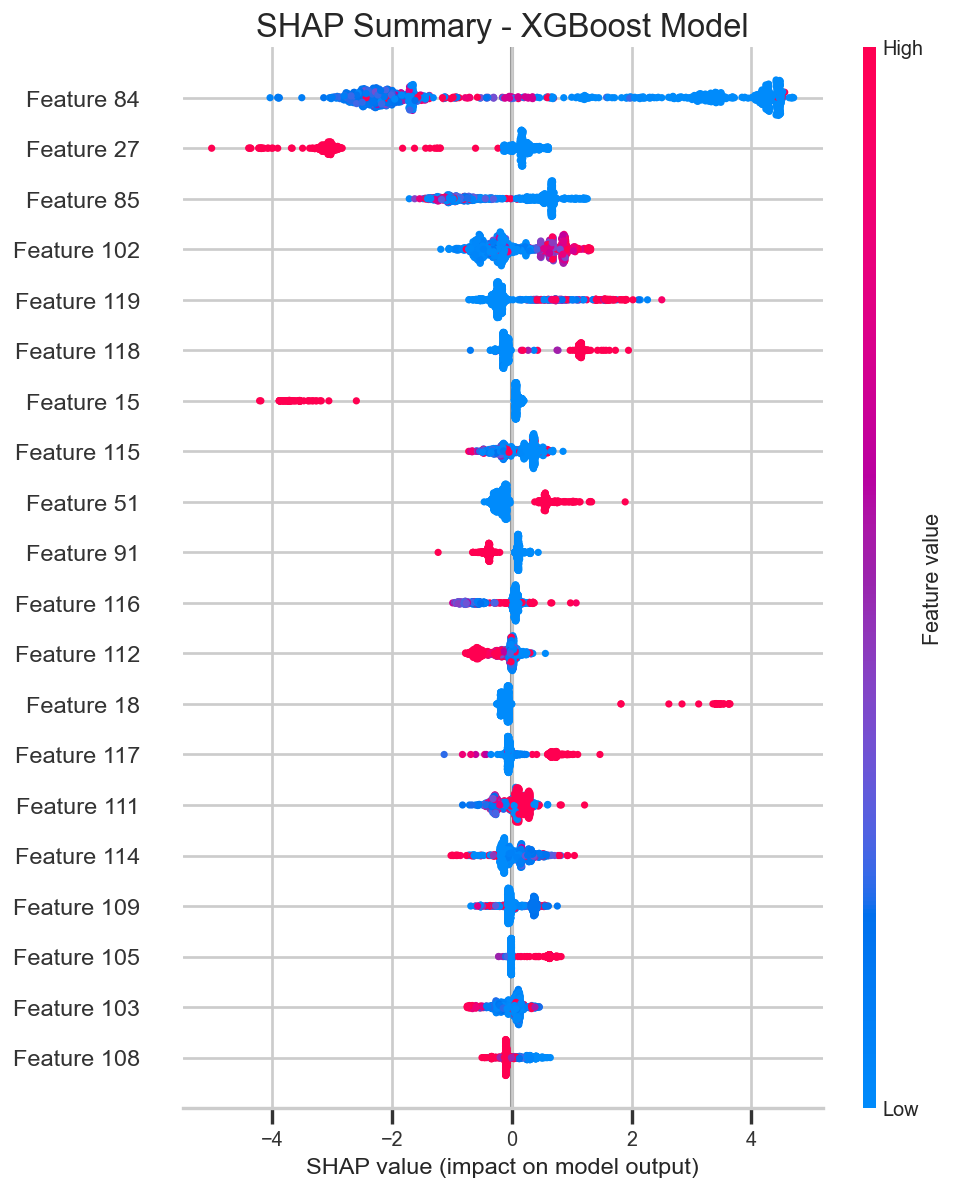

In [16]:
try:
    import importlib

    shap = importlib.import_module('shap')
    xgb_model_existing = _get_existing_variable('xgb_model')

    # Use the exact matrix already aligned to the loaded XGBoost model.
    if 'xgb_eval' in globals():
        X_shap = np.asarray(globals()['xgb_eval'])
    elif 'X_test_pre' in globals():
        X_shap = np.asarray(globals()['X_test_pre'])
    elif 'X_test' in globals():
        X_shap = np.asarray(globals()['X_test'])
    else:
        raise ValueError('No compatible feature matrix found for SHAP.')

    expected_features = int(getattr(xgb_model_existing, 'n_features_in_'))
    if X_shap.shape[1] != expected_features:
        raise ValueError(
            f'SHAP input feature mismatch: got {X_shap.shape[1]} columns, expected {expected_features}.'
        )

    sample_size = min(1000, X_shap.shape[0])
    X_shap_sample = X_shap[:sample_size]

    explainer = shap.TreeExplainer(xgb_model_existing)
    shap_values = explainer.shap_values(X_shap_sample)

    plt.figure(figsize=(14, 8))
    shap.summary_plot(shap_values, X_shap_sample, show=False)
    plt.title('SHAP Summary - XGBoost Model')
    plt.tight_layout()
    plt.savefig(figures_dir / 'shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
except Exception as ex:
    print('SHAP summary skipped:', ex)
    print('Install SHAP or ensure compatible XGBoost inputs are available.')

### 7) Model Performance Comparison Bar Chart

This chart compares core classification metrics across baseline, XGBoost, CNN, and Hybrid models.

Why it matters:
- Multi-metric comparison prevents over-reliance on a single score.
- It reveals whether gains in recall are achieved without severe precision loss.

Insight focus:
- Strong hybrid performance across recall and ROC-AUC indicates robust attack prioritization.

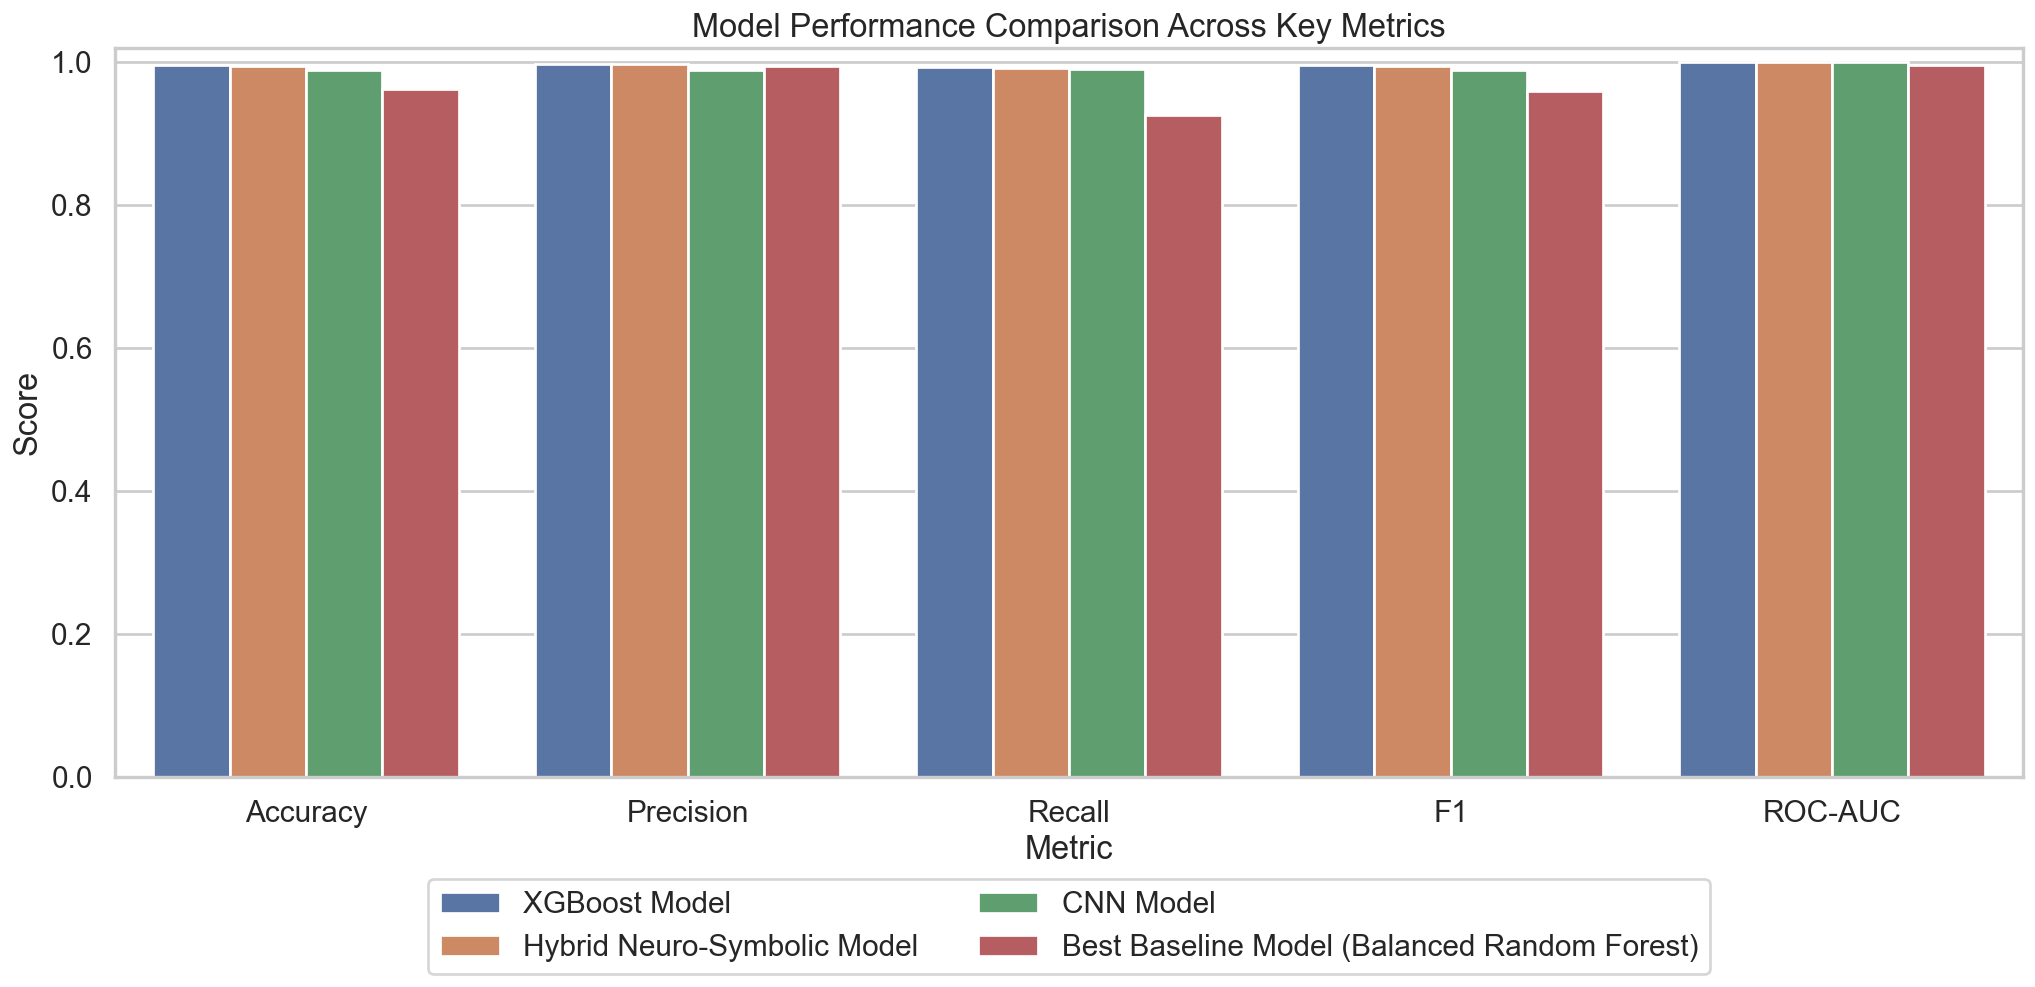

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost Model,0.9956,0.9970,0.9938,0.9954,0.9999
1,Hybrid Neuro-Symbolic Model,0.9948,0.9980,0.9912,0.9946,0.9999
2,CNN Model,0.9896,0.9887,0.9896,0.9892,0.9995
3,Best Baseline Model (Balanced Random Forest),0.9622,0.9945,0.9266,0.9594,0.9965


In [18]:
if 'hybrid_comparison_df' in globals() and isinstance(hybrid_comparison_df, pd.DataFrame):
    perf_df = hybrid_comparison_df.copy()
else:
    perf_df = pd.DataFrame([
        {
            'Model': f'Best Baseline ({baseline_name})',
            'Accuracy': accuracy_score(y_true, y_pred_baseline),
            'Precision': precision_score(y_true, y_pred_baseline, zero_division=0),
            'Recall': recall_score(y_true, y_pred_baseline, zero_division=0),
            'F1': f1_score(y_true, y_pred_baseline, zero_division=0),
            'ROC-AUC': roc_auc_score(y_true, baseline_score),
        },
        {
            'Model': 'XGBoost',
            'Accuracy': accuracy_score(y_true, y_pred_xgb),
            'Precision': precision_score(y_true, y_pred_xgb, zero_division=0),
            'Recall': recall_score(y_true, y_pred_xgb, zero_division=0),
            'F1': f1_score(y_true, y_pred_xgb, zero_division=0),
            'ROC-AUC': roc_auc_score(y_true, xgb_proba),
        },
        {
            'Model': 'CNN Model 2 (Deep)',
            'Accuracy': accuracy_score(y_true, y_pred_cnn),
            'Precision': precision_score(y_true, y_pred_cnn, zero_division=0),
            'Recall': recall_score(y_true, y_pred_cnn, zero_division=0),
            'F1': f1_score(y_true, y_pred_cnn, zero_division=0),
            'ROC-AUC': roc_auc_score(y_true, cnn_proba),
        },
        {
            'Model': 'Hybrid Neuro-Symbolic',
            'Accuracy': accuracy_score(y_true, y_pred_hybrid),
            'Precision': precision_score(y_true, y_pred_hybrid, zero_division=0),
            'Recall': recall_score(y_true, y_pred_hybrid, zero_division=0),
            'F1': f1_score(y_true, y_pred_hybrid, zero_division=0),
            'ROC-AUC': roc_auc_score(y_true, hybrid_score),
        },
    ])

plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
plot_perf_df = perf_df[['Model'] + plot_metrics].copy()
plot_perf_long = plot_perf_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 8))
sns.barplot(data=plot_perf_long, x='Metric', y='Score', hue='Model')
plt.ylim(0, 1.02)
plt.title('Model Performance Comparison Across Key Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)
plt.tight_layout()
plt.savefig(figures_dir / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

display(plot_perf_df.round(4))

### 8) Error Analysis Visualization

This view isolates false positives and false negatives and examines confidence behavior.

Why it matters:
- False positives increase analyst workload.
- False negatives are high-risk misses in security operations.

Insight focus:
- Confidence distributions reveal whether misclassifications are near-threshold uncertainty or high-confidence mistakes.

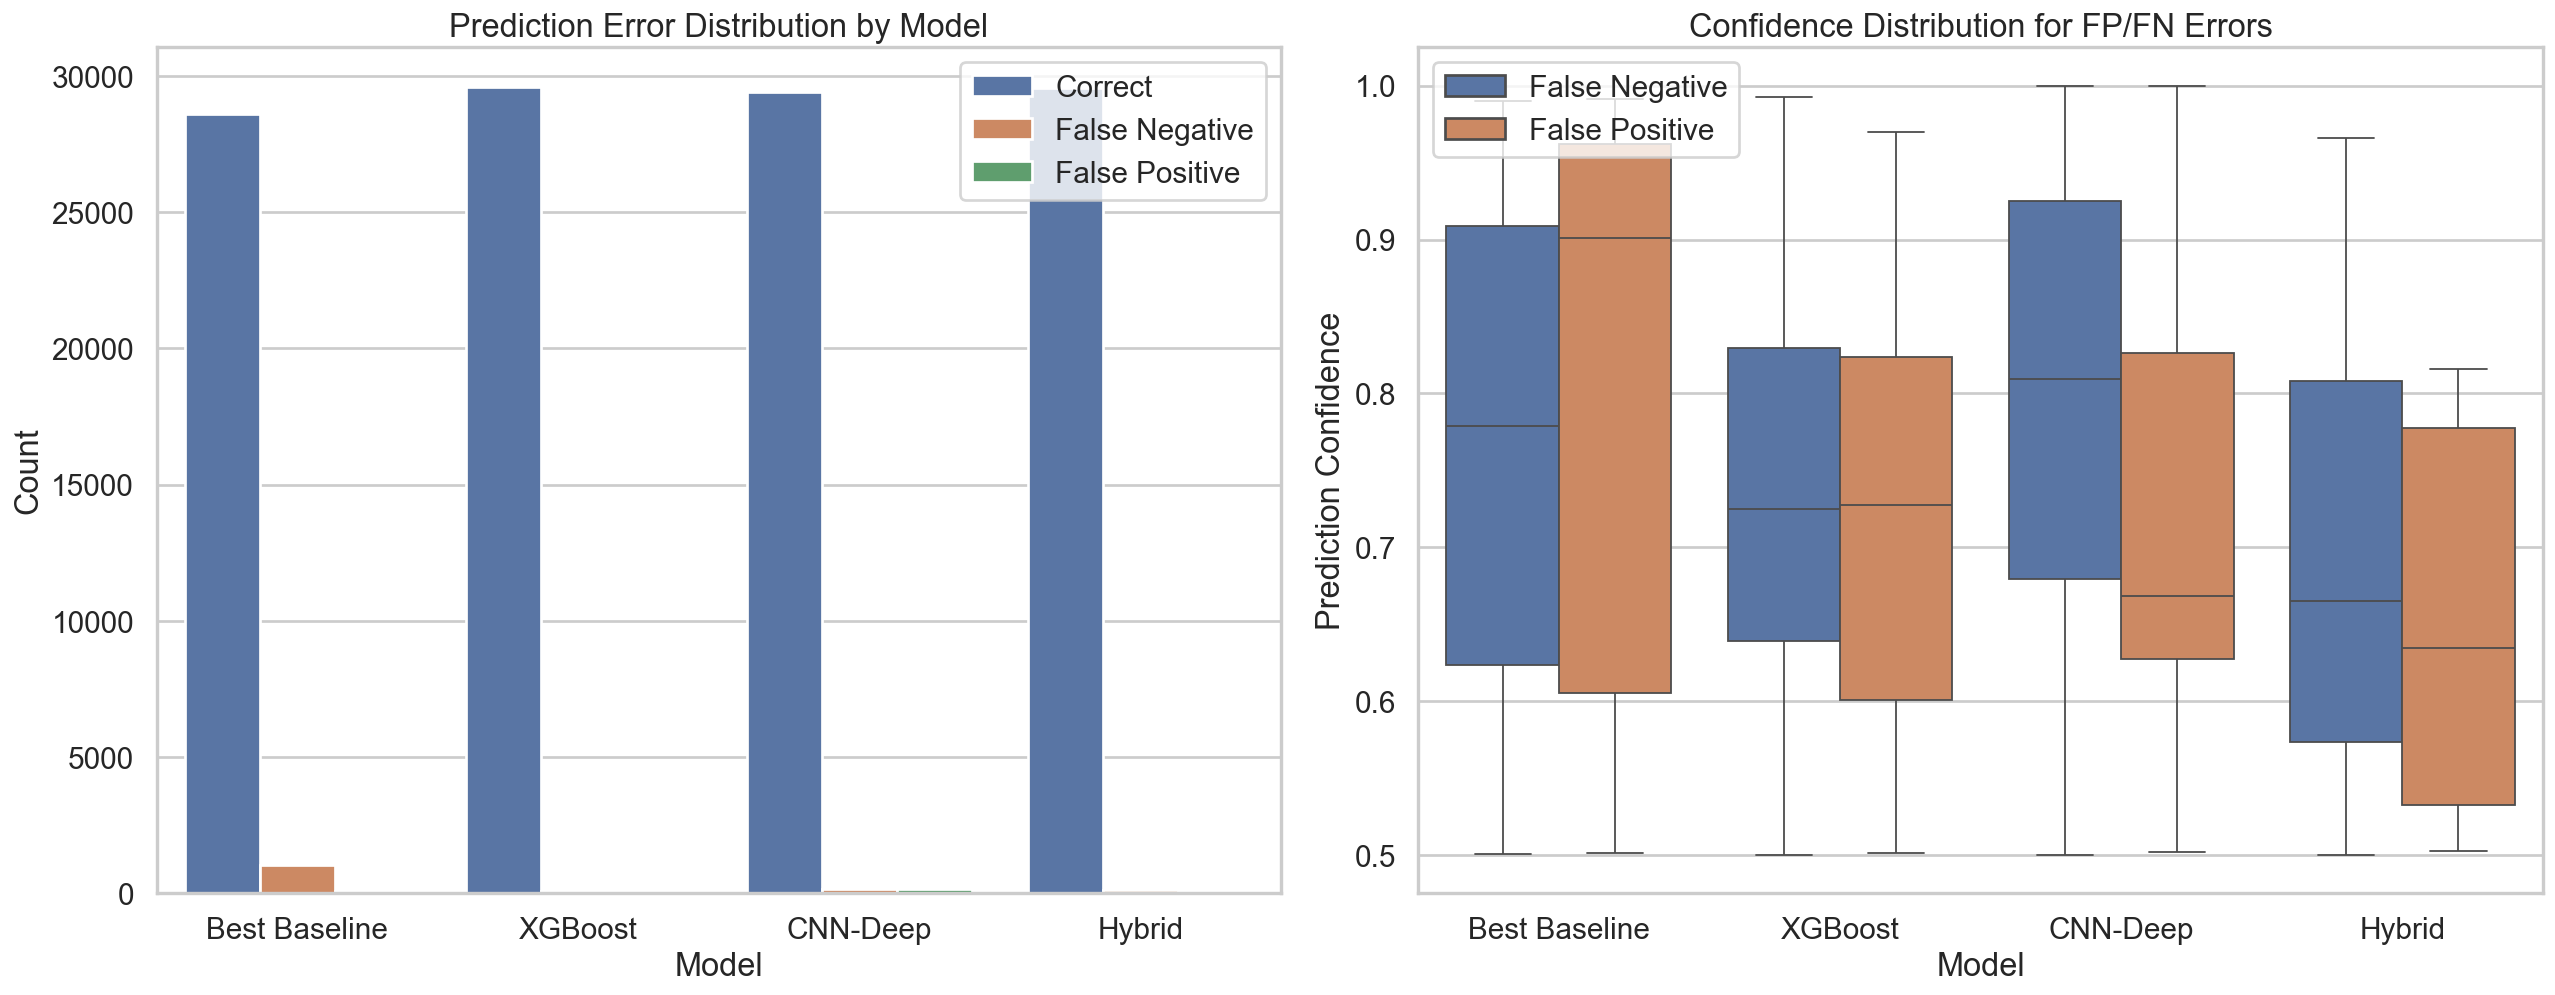

,Model,Error Type,Count
0,Best Baseline (Balanced Random Forest),Correct,28582
1,Best Baseline (Balanced Random Forest),False Negative,1049
2,Best Baseline (Balanced Random Forest),False Positive,73
3,CNN Model 2 (Deep),Correct,29395
4,CNN Model 2 (Deep),False Negative,148
5,CNN Model 2 (Deep),False Positive,161
6,Hybrid Neuro-Symbolic,Correct,29550
7,Hybrid Neuro-Symbolic,False Negative,126
8,Hybrid Neuro-Symbolic,False Positive,28
9,XGBoost,Correct,29572


In [20]:
error_rows = []

for model_name, y_pred_model in predictions_map.items():
    model_scores = scores_map[model_name]
    pred_conf = np.where(y_pred_model == 1, model_scores, 1.0 - model_scores)

    error_type = np.where(
        (y_true == 0) & (y_pred_model == 1),
        'False Positive',
        np.where((y_true == 1) & (y_pred_model == 0), 'False Negative', 'Correct'),
    )

    for idx in range(len(y_true)):
        error_rows.append({
            'Model': model_name,
            'Error Type': error_type[idx],
            'Confidence': float(pred_conf[idx]),
            'Absolute Error': int(y_true[idx] != y_pred_model[idx]),
        })

error_df = pd.DataFrame(error_rows)
error_only_df = error_df[error_df['Error Type'] != 'Correct'].copy()

label_map = {
    f'Best Baseline ({baseline_name})': 'Best Baseline',
    'XGBoost': 'XGBoost',
    'CNN Model 2 (Deep)': 'CNN-Deep',
    'Hybrid Neuro-Symbolic': 'Hybrid',
}
error_df['Model Short'] = error_df['Model'].map(label_map).fillna(error_df['Model'])
error_only_df['Model Short'] = error_only_df['Model'].map(label_map).fillna(error_only_df['Model'])
model_order = ['Best Baseline', 'XGBoost', 'CNN-Deep', 'Hybrid']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.countplot(
    data=error_df,
    x='Model Short',
    hue='Error Type',
    order=model_order,
    ax=axes[0],
)
axes[0].set_title('Prediction Error Distribution by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='upper right', frameon=True)

if not error_only_df.empty:
    sns.boxplot(
        data=error_only_df,
        x='Model Short',
        y='Confidence',
        hue='Error Type',
        order=model_order,
        ax=axes[1],
    )
    axes[1].set_title('Confidence Distribution for FP/FN Errors')
    axes[1].set_xlabel('Model')
    axes[1].set_ylabel('Prediction Confidence')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(loc='upper left', frameon=True)
else:
    axes[1].text(0.5, 0.5, 'No FP/FN errors to plot', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(figures_dir / 'error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

error_summary = (
    error_df.groupby(['Model', 'Error Type'])['Absolute Error']
    .count()
    .reset_index(name='Count')
)
display(error_summary)

### 9) Visualization Export Summary

Saved to figures/:
- confusion_matrix.png
- roc_curve.png
- pr_curve.png
- feature_heatmap.png
- model_comparison.png

Additional supporting exports (optional):
- shap_summary.png (if SHAP succeeds)
- error_analysis.png

These figures are formatted for research reporting and comparative model interpretation.